
Selected route videos:
Route 1: route_1.mp4
Route 2: route_2.mp4
Route 3: route_3.mp4

Selected query video:
query_video.mp4

Extracting route frames...
Route 1: saved 50 frames from first 20.00s
Route 2: saved 50 frames from first 19.10s
Route 3: saved 50 frames from first 20.00s

Extracting query video candidate frames...
Query video: saved 50 frames from first 20.00s

✅ Frame extraction complete.
Report saved to: C:\Users\progr\JupyterNotebook\Untitled Folder\extracted_frames\frame_extraction_report.json


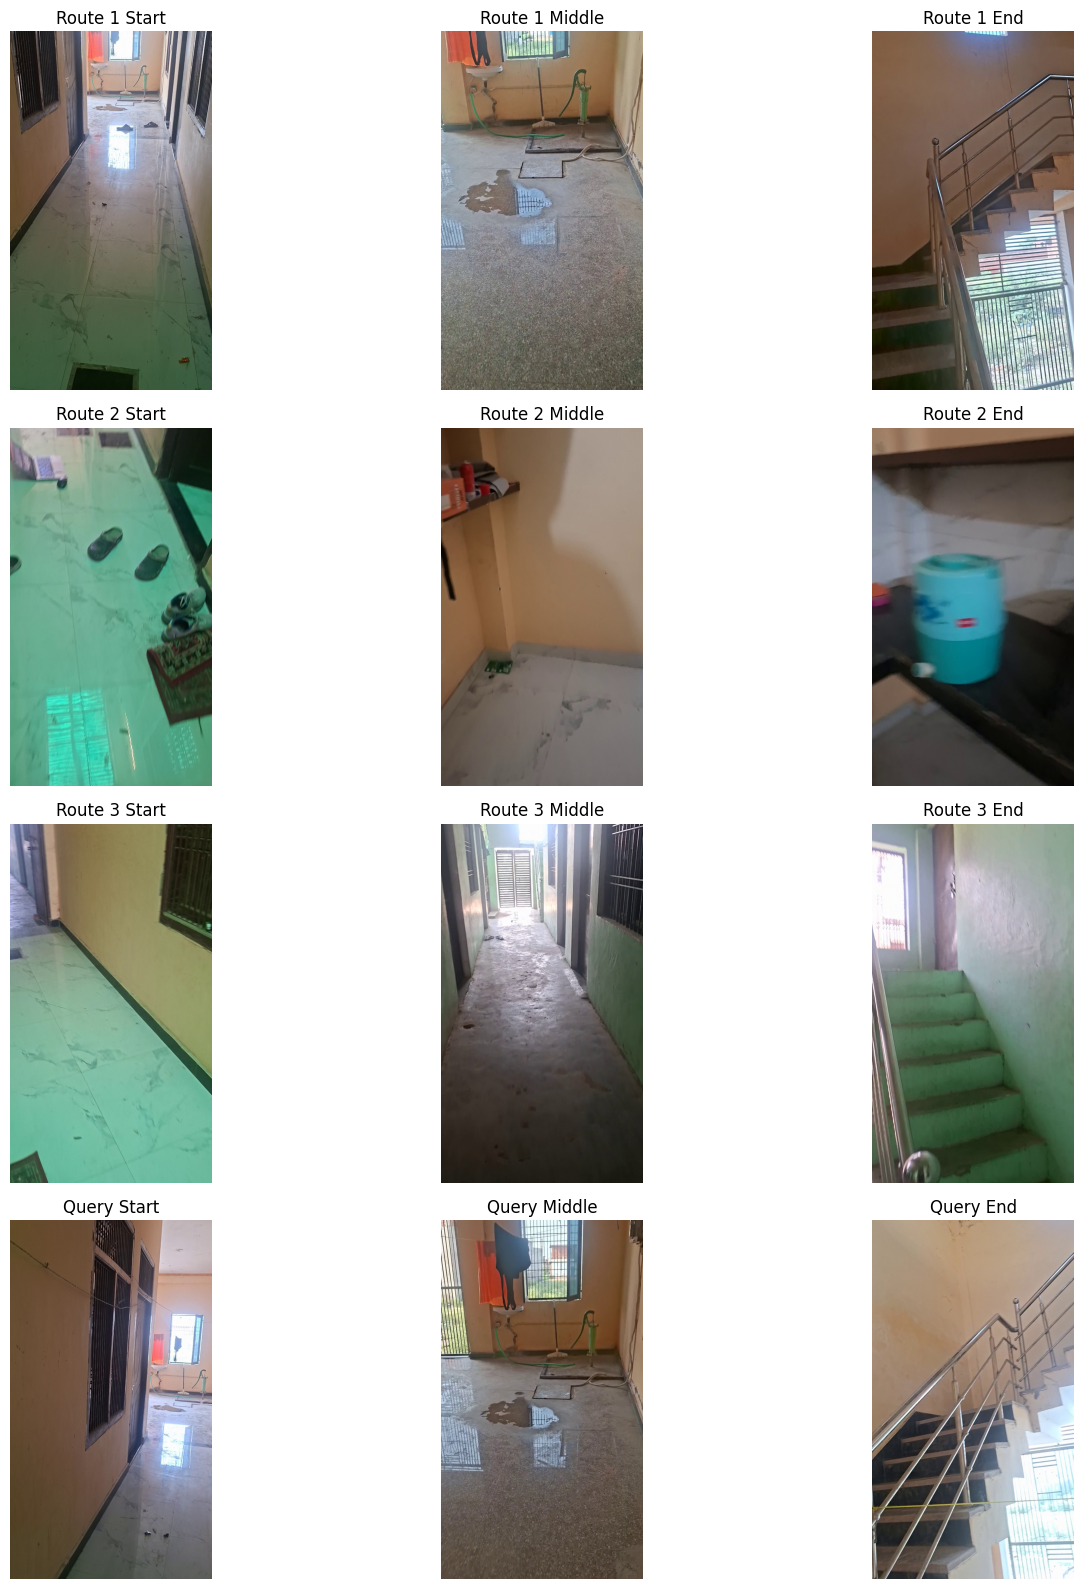

In [1]:
# ============================================================
# CELL 1: VIDEO CLIP + FRAME EXTRACTION
# VXN-RAMNet Final Video Route System
#
# Purpose:
# - Take 3 route videos.
# - Use only first 20 seconds of each video.
# - Extract 50 evenly spaced frames from each route video.
# - Take 4th video as query/test video.
# - Use only first 20 seconds of query video.
# - Extract 50 candidate frames from query video.
#
# Output:
# - extracted_frames/route_1/
# - extracted_frames/route_2/
# - extracted_frames/route_3/
# - extracted_frames/query_video/
# ============================================================

import sys
import subprocess
from pathlib import Path
import shutil
import json
import time

# ------------------------------------------------------------
# 1. Auto-install dependencies
# ------------------------------------------------------------

def install_if_missing(package_name, import_name=None):
    try:
        __import__(import_name or package_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

install_if_missing("opencv-python", "cv2")
install_if_missing("numpy", "numpy")
install_if_missing("pandas", "pandas")
install_if_missing("pillow", "PIL")
install_if_missing("matplotlib", "matplotlib")

import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 2. Configuration
# ------------------------------------------------------------

ROOT_DIR = Path(".")
VIDEOS_DIR = ROOT_DIR / "videos"

OUTPUT_FRAMES_DIR = ROOT_DIR / "extracted_frames"

MAX_VIDEO_SECONDS = 20
ROUTE_FRAMES_PER_VIDEO = 50
QUERY_CANDIDATE_FRAMES = 50

VIDEO_EXTENSIONS = [".mp4", ".mov", ".avi", ".mkv", ".webm"]

# Option A: recommended manual filenames
ROUTE_VIDEO_FILES = [
    "route_1.mp4",
    "route_2.mp4",
    "route_3.mp4"
]

QUERY_VIDEO_FILE = "query_video.mp4"


# ------------------------------------------------------------
# 3. Locate videos
# ------------------------------------------------------------

def find_video_file(filename):
    possible_paths = [
        VIDEOS_DIR / filename,
        ROOT_DIR / filename
    ]

    for path in possible_paths:
        if path.exists():
            return path

    return None

route_video_paths = []
missing_manual_files = False

for filename in ROUTE_VIDEO_FILES:
    found = find_video_file(filename)
    if found is None:
        missing_manual_files = True
        break
    route_video_paths.append(found)

query_video_path = find_video_file(QUERY_VIDEO_FILE)

# Auto-detect fallback if manual names are missing
if missing_manual_files or query_video_path is None:
    print("Manual video names not fully found. Trying auto-detection...")

    search_dirs = []
    if VIDEOS_DIR.exists():
        search_dirs.append(VIDEOS_DIR)
    search_dirs.append(ROOT_DIR)

    all_videos = []

    for folder in search_dirs:
        for file in folder.iterdir():
            if file.is_file() and file.suffix.lower() in VIDEO_EXTENSIONS:
                all_videos.append(file)

    all_videos = sorted(list(set(all_videos)))

    if len(all_videos) < 4:
        raise FileNotFoundError(
            "At least 4 videos are required.\n\n"
            "Recommended structure:\n"
            "videos/route_1.mp4\n"
            "videos/route_2.mp4\n"
            "videos/route_3.mp4\n"
            "videos/query_video.mp4\n\n"
            f"Videos found: {len(all_videos)}"
        )

    route_video_paths = all_videos[:3]
    query_video_path = all_videos[3]

print("\nSelected route videos:")
for idx, path in enumerate(route_video_paths, start=1):
    print(f"Route {idx}: {path}")

print("\nSelected query video:")
print(query_video_path)


# ------------------------------------------------------------
# 4. Clean output folder
# ------------------------------------------------------------

if OUTPUT_FRAMES_DIR.exists():
    shutil.rmtree(OUTPUT_FRAMES_DIR)

OUTPUT_FRAMES_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 5. Video utility functions
# ------------------------------------------------------------

def get_video_info(video_path):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps <= 0:
        fps = 30.0

    duration = total_frames / fps if fps > 0 else 0

    cap.release()

    return {
        "fps": fps,
        "total_frames": total_frames,
        "duration_seconds": duration
    }

def extract_evenly_spaced_frames(video_path, output_folder, frame_count, max_seconds=20):
    """
    Uses only first max_seconds of video.
    Does not need to physically save clipped video.
    It samples frames only from the first max_seconds.
    This acts as logical clipping.
    """

    output_folder.mkdir(parents=True, exist_ok=True)

    info = get_video_info(video_path)

    fps = info["fps"]
    total_frames = info["total_frames"]
    duration = info["duration_seconds"]

    usable_seconds = min(duration, max_seconds)
    usable_frame_count = int(usable_seconds * fps)

    if usable_frame_count <= 0:
        raise ValueError(f"Video has no usable frames: {video_path}")

    # Ensure we do not sample beyond actual frames
    usable_frame_count = min(usable_frame_count, total_frames)

    # Evenly spaced frame indices from start to clipped end
    frame_indices = np.linspace(
        0,
        max(0, usable_frame_count - 1),
        frame_count,
        dtype=int
    )

    cap = cv2.VideoCapture(str(video_path))

    saved_paths = []

    for out_idx, frame_idx in enumerate(frame_indices, start=1):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        success, frame = cap.read()

        if not success:
            print(f"Warning: Could not read frame {frame_idx} from {video_path.name}")
            continue

        # Save as JPEG
        output_path = output_folder / f"frame_{out_idx:03d}.jpg"

        cv2.imwrite(str(output_path), frame)
        saved_paths.append(output_path)

    cap.release()

    return {
        "video_path": str(video_path),
        "fps": fps,
        "original_duration_seconds": duration,
        "used_duration_seconds": usable_seconds,
        "original_total_frames": total_frames,
        "used_frame_count": usable_frame_count,
        "requested_output_frames": frame_count,
        "saved_output_frames": len(saved_paths),
        "output_folder": str(output_folder)
    }


# ------------------------------------------------------------
# 6. Extract route frames
# ------------------------------------------------------------

extraction_report = {
    "system": "VXN-RAMNet",
    "stage": "video_frame_extraction",
    "max_video_seconds": MAX_VIDEO_SECONDS,
    "route_frames_per_video": ROUTE_FRAMES_PER_VIDEO,
    "query_candidate_frames": QUERY_CANDIDATE_FRAMES,
    "created_at_unix": time.time(),
    "routes": [],
    "query": None
}

print("\nExtracting route frames...")

for route_idx, video_path in enumerate(route_video_paths, start=1):
    route_folder = OUTPUT_FRAMES_DIR / f"route_{route_idx}"

    report = extract_evenly_spaced_frames(
        video_path=video_path,
        output_folder=route_folder,
        frame_count=ROUTE_FRAMES_PER_VIDEO,
        max_seconds=MAX_VIDEO_SECONDS
    )

    extraction_report["routes"].append(report)

    print(
        f"Route {route_idx}: saved {report['saved_output_frames']} frames "
        f"from first {report['used_duration_seconds']:.2f}s"
    )


# ------------------------------------------------------------
# 7. Extract query candidate frames
# ------------------------------------------------------------

print("\nExtracting query video candidate frames...")

query_folder = OUTPUT_FRAMES_DIR / "query_video"

query_report = extract_evenly_spaced_frames(
    video_path=query_video_path,
    output_folder=query_folder,
    frame_count=QUERY_CANDIDATE_FRAMES,
    max_seconds=MAX_VIDEO_SECONDS
)

extraction_report["query"] = query_report

print(
    f"Query video: saved {query_report['saved_output_frames']} frames "
    f"from first {query_report['used_duration_seconds']:.2f}s"
)


# ------------------------------------------------------------
# 8. Save extraction report
# ------------------------------------------------------------

report_path = OUTPUT_FRAMES_DIR / "frame_extraction_report.json"

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(extraction_report, f, indent=2)

print("\n✅ Frame extraction complete.")
print("Report saved to:", report_path.resolve())


# ------------------------------------------------------------
# 9. Quick preview
# ------------------------------------------------------------

preview_images = []

for route_idx in range(1, 4):
    folder = OUTPUT_FRAMES_DIR / f"route_{route_idx}"
    frames = sorted(folder.glob("*.jpg"))
    if frames:
        preview_images.append((frames[0], f"Route {route_idx} Start"))
        preview_images.append((frames[len(frames)//2], f"Route {route_idx} Middle"))
        preview_images.append((frames[-1], f"Route {route_idx} End"))

query_frames = sorted(query_folder.glob("*.jpg"))
if query_frames:
    preview_images.append((query_frames[0], "Query Start"))
    preview_images.append((query_frames[len(query_frames)//2], "Query Middle"))
    preview_images.append((query_frames[-1], "Query End"))

cols = 3
rows = int(np.ceil(len(preview_images) / cols))

plt.figure(figsize=(15, rows * 4))

for i, (img_path, title) in enumerate(preview_images, start=1):
    img = Image.open(img_path).convert("RGB")
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)

plt.tight_layout()
plt.show()

In [2]:
# ============================================================
# CELL 2: FAST ROUTE MEMORY ENCODING FROM EXTRACTED FRAMES
# VXN-RAMNet Final Video Route Memory
#
# Purpose:
# - Read extracted route frames.
# - Encode route_1, route_2, route_3.
# - Save embeddings, labels, route centroids, metadata.
#
# Fast design:
# - EfficientNetB0 frozen encoder
# - Batch inference
# - Single-frame embeddings
# - L2 normalization
# - .npz fast memory file
# ============================================================

import sys
import subprocess
from pathlib import Path
import json
import time

def install_if_missing(package_name, import_name=None):
    try:
        __import__(import_name or package_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

install_if_missing("tensorflow", "tensorflow")
install_if_missing("pillow", "PIL")
install_if_missing("numpy", "numpy")
install_if_missing("pandas", "pandas")

import numpy as np
import pandas as pd
from PIL import Image, ImageOps

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

ROOT_DIR = Path(".")
EXTRACTED_FRAMES_DIR = ROOT_DIR / "extracted_frames"

ROUTE_FOLDERS = [
    EXTRACTED_FRAMES_DIR / "route_1",
    EXTRACTED_FRAMES_DIR / "route_2",
    EXTRACTED_FRAMES_DIR / "route_3"
]

OUTPUT_MEMORY_NPZ = ROOT_DIR / "vxn_video_route_memory.npz"
OUTPUT_METADATA_JSON = ROOT_DIR / "vxn_video_route_metadata.json"

MODEL_INPUT_SIZE = (224, 224)
BATCH_SIZE = 16

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]

for folder in ROUTE_FOLDERS:
    if not folder.exists():
        raise FileNotFoundError(
            f"Route frame folder not found: {folder.resolve()}\n"
            "Run Cell 1 first."
        )


# ------------------------------------------------------------
# 2. Collect route frame paths
# ------------------------------------------------------------

all_image_paths = []
all_labels = []
route_names = []

for route_idx, folder in enumerate(ROUTE_FOLDERS):
    route_name = folder.name
    route_names.append(route_name)

    frames = sorted([
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    if len(frames) == 0:
        raise FileNotFoundError(f"No frames found in {folder}")

    print(f"{route_name}: {len(frames)} frames")

    for frame_path in frames:
        all_image_paths.append(frame_path)
        all_labels.append(route_idx)

all_labels = np.array(all_labels, dtype=np.int32)

print("\nTotal route memory frames:", len(all_image_paths))
print("Routes:", route_names)


# ------------------------------------------------------------
# 3. Load EfficientNetB0 frozen encoder
# ------------------------------------------------------------

print("\nLoading EfficientNetB0 frozen encoder...")
print("First run may download ImageNet weights automatically.")

encoder = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

encoder.trainable = False

# Warm-up
dummy = np.zeros((1, 224, 224, 3), dtype=np.float32)
_ = encoder.predict(dummy, verbose=0)

print("✅ Encoder loaded and warmed up.")
print("Embedding dimension:", encoder.output_shape[-1])


# ------------------------------------------------------------
# 4. Fast preprocessing
# ------------------------------------------------------------

def load_image_fast(img_path, target_size=MODEL_INPUT_SIZE):
    img = Image.open(img_path).convert("RGB")
    img = ImageOps.exif_transpose(img)
    img = img.resize(target_size)
    arr = keras_image.img_to_array(img)
    return arr

def build_batches(image_paths, batch_size=BATCH_SIZE):
    batch = []
    batch_paths = []

    for img_path in image_paths:
        arr = load_image_fast(img_path)
        batch.append(arr)
        batch_paths.append(str(img_path.as_posix()))

        if len(batch) == batch_size:
            batch_np = np.array(batch, dtype=np.float32)
            batch_np = preprocess_input(batch_np)
            yield batch_np, batch_paths

            batch = []
            batch_paths = []

    if len(batch) > 0:
        batch_np = np.array(batch, dtype=np.float32)
        batch_np = preprocess_input(batch_np)
        yield batch_np, batch_paths

def l2_normalize_matrix(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return matrix / norms


# ------------------------------------------------------------
# 5. Batch encode all route memory frames
# ------------------------------------------------------------

all_embeddings = []
all_paths_text = []

start_time = time.time()

print("\nEncoding route frames...")

processed = 0

for batch_np, batch_paths in build_batches(all_image_paths):
    emb = encoder.predict(batch_np, verbose=0)
    emb = l2_normalize_matrix(emb)

    all_embeddings.append(emb.astype(np.float32))
    all_paths_text.extend(batch_paths)

    processed += len(batch_paths)
    print(f"Encoded {processed}/{len(all_image_paths)} frames")

all_embeddings = np.vstack(all_embeddings).astype(np.float32)

encoding_time = time.time() - start_time

print("\n✅ Route encoding complete.")
print("Embedding matrix shape:", all_embeddings.shape)
print(f"Total encoding time: {encoding_time:.2f} sec")
print(f"Average encoding time per frame: {(encoding_time / len(all_image_paths)) * 1000:.2f} ms")


# ------------------------------------------------------------
# 6. Create route centroids
# ------------------------------------------------------------

route_centroids = []

for route_idx in range(len(route_names)):
    route_embeddings = all_embeddings[all_labels == route_idx]

    centroid = np.mean(route_embeddings, axis=0, keepdims=True)
    centroid = l2_normalize_matrix(centroid)[0]

    route_centroids.append(centroid)

route_centroids = np.vstack(route_centroids).astype(np.float32)

print("\n✅ Route centroids created.")
print("Centroid shape:", route_centroids.shape)


# ------------------------------------------------------------
# 7. Save fast memory files
# ------------------------------------------------------------

np.savez_compressed(
    OUTPUT_MEMORY_NPZ,
    embeddings=all_embeddings,
    labels=all_labels,
    centroids=route_centroids,
    route_names=np.array(route_names),
    image_paths=np.array(all_paths_text)
)

metadata = {
    "system": "VXN-RAMNet",
    "stage": "video_route_memory_encoding",
    "gps_used": False,
    "model_retraining_used": False,
    "model": "EfficientNetB0",
    "model_input_size": MODEL_INPUT_SIZE,
    "embedding_method": "single_frame_l2_normalized",
    "storage": "npz_fast_binary",
    "total_routes": len(route_names),
    "route_names": route_names,
    "total_memory_frames": len(all_image_paths),
    "route_frames_per_video": {
        route_name: int(np.sum(all_labels == idx))
        for idx, route_name in enumerate(route_names)
    },
    "created_at_unix": time.time(),
    "runtime_note": "Use this .npz for fast real-time route classification."
}

with open(OUTPUT_METADATA_JSON, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("\n✅ Fast route memory saved.")
print("Memory file:", OUTPUT_MEMORY_NPZ.resolve())
print("Metadata file:", OUTPUT_METADATA_JSON.resolve())

print("\nImportant:")
print("No training happened.")
print("No fine-tuning happened.")
print("Only route memory embeddings were created.")

route_1: 50 frames
route_2: 50 frames
route_3: 50 frames

Total route memory frames: 150
Routes: ['route_1', 'route_2', 'route_3']

Loading EfficientNetB0 frozen encoder...
First run may download ImageNet weights automatically.
✅ Encoder loaded and warmed up.
Embedding dimension: 1280

Encoding route frames...
Encoded 16/150 frames
Encoded 32/150 frames
Encoded 48/150 frames
Encoded 64/150 frames
Encoded 80/150 frames
Encoded 96/150 frames
Encoded 112/150 frames
Encoded 128/150 frames
Encoded 144/150 frames
Encoded 150/150 frames

✅ Route encoding complete.
Embedding matrix shape: (150, 1280)
Total encoding time: 5.77 sec
Average encoding time per frame: 38.49 ms

✅ Route centroids created.
Centroid shape: (3, 1280)

✅ Fast route memory saved.
Memory file: C:\Users\progr\JupyterNotebook\Untitled Folder\vxn_video_route_memory.npz
Metadata file: C:\Users\progr\JupyterNotebook\Untitled Folder\vxn_video_route_metadata.json

Important:
No training happened.
No fine-tuning happened.
Only rou

✅ Route memory loaded.
Routes: ['route_1', 'route_2', 'route_3']
Memory embeddings: (150, 1280)
Memory load time: 45.46 ms

Query candidate frames: 50

Loading EfficientNetB0 frozen encoder...
✅ Encoder loaded and warmed up.

--------------------------------
Evidence frames used: 1
Decision: CONFIRMED_ROUTE
Prediction: route_1
Best score: 0.7615
Gap: 0.0924
Stability: 1.0
Stage time: 105.75 ms

PROGRESSIVE EVIDENCE REPORT


,evidence_frames_used,inference_ms,scoring_ms,total_stage_ms,decision_state,prediction,best_score,gap,stability,reason
0,1,105.05724,0.688076,105.745316,CONFIRMED_ROUTE,route_1,0.761513,0.092358,1.0,Route is reasonably stronger after evidence co...



FINAL AGGREGATED ROUTE EVIDENCE


,Rank,Route,Average Score,Max Score,Min Score,Rank-1 Votes,Stability
0,1,route_1,0.7615,0.7615,0.7615,1,1.0
1,2,route_3,0.6692,0.6692,0.6692,0,0.0
2,3,route_2,0.5433,0.5433,0.5433,0,0.0



FINAL VXN-RAMNet QUERY VIDEO DECISION
Final state: CONFIRMED_ROUTE
Prediction: route_1
Reason: Route is reasonably stronger after evidence collection
Best average score: 0.7615
Confidence gap: 0.0924
Stability: 1.0
Total progressive classification time: 112.62 ms

✅ Route confirmed successfully.

Speed check:
Last evidence stage time: 105.75 ms
✅ This stage is within 2 FPS target: under 500 ms.


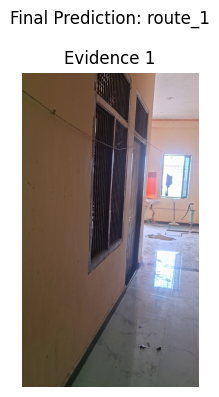


✅ Query classification report saved to:
C:\Users\progr\JupyterNotebook\Untitled Folder\vxn_query_video_classification_report.json


In [3]:
# ============================================================
# CELL 3: QUERY VIDEO ROUTE CLASSIFICATION WITH EVIDENCE MODE
# VXN-RAMNet Final Query Video Classifier
#
# Purpose:
# - Load query video frames extracted in Cell 1.
# - Start with 1 frame.
# - If uncertain, use more frames.
# - Classify query video as route_1, route_2, or route_3.
# - Measure speed in milliseconds.
#
# Decision:
# - CONFIRMED_ROUTE
# - UNCERTAIN_ROUTE
# - UNKNOWN_ROUTE
# ============================================================

import sys
import subprocess
from pathlib import Path
import json
import time

def install_if_missing(package_name, import_name=None):
    try:
        __import__(import_name or package_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

install_if_missing("tensorflow", "tensorflow")
install_if_missing("pillow", "PIL")
install_if_missing("numpy", "numpy")
install_if_missing("pandas", "pandas")
install_if_missing("matplotlib", "matplotlib")

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

ROOT_DIR = Path(".")

EXTRACTED_FRAMES_DIR = ROOT_DIR / "extracted_frames"
QUERY_FRAMES_DIR = EXTRACTED_FRAMES_DIR / "query_video"

MEMORY_NPZ = ROOT_DIR / "vxn_video_route_memory.npz"

MODEL_INPUT_SIZE = (224, 224)

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]

# Evidence strategy
EVIDENCE_FRAME_COUNTS = [1, 3, 5, 7, 9]

# Decision thresholds
MIN_ROUTE_SCORE = 0.70
MIN_CONFIDENCE_GAP = 0.035
MIN_STABILITY = 0.60

# These can be tuned after results
STRONG_ROUTE_SCORE = 0.78
STRONG_GAP = 0.05

if not QUERY_FRAMES_DIR.exists():
    raise FileNotFoundError(
        f"Query frames folder not found: {QUERY_FRAMES_DIR.resolve()}\n"
        "Run Cell 1 first."
    )

if not MEMORY_NPZ.exists():
    raise FileNotFoundError(
        f"Memory file not found: {MEMORY_NPZ.resolve()}\n"
        "Run Cell 2 first."
    )


# ------------------------------------------------------------
# 2. Load memory
# ------------------------------------------------------------

memory_load_start = time.time()

memory = np.load(MEMORY_NPZ, allow_pickle=True)

memory_embeddings = memory["embeddings"].astype(np.float32)
memory_labels = memory["labels"].astype(np.int32)
route_centroids = memory["centroids"].astype(np.float32)
route_names = memory["route_names"].tolist()
image_paths = memory["image_paths"].tolist()

memory_load_ms = (time.time() - memory_load_start) * 1000

print("✅ Route memory loaded.")
print("Routes:", route_names)
print("Memory embeddings:", memory_embeddings.shape)
print(f"Memory load time: {memory_load_ms:.2f} ms")


# ------------------------------------------------------------
# 3. Load query frames
# ------------------------------------------------------------

query_frames = sorted([
    p for p in QUERY_FRAMES_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

if len(query_frames) == 0:
    raise FileNotFoundError("No query frames found.")

print("\nQuery candidate frames:", len(query_frames))


# ------------------------------------------------------------
# 4. Load encoder once
# ------------------------------------------------------------

print("\nLoading EfficientNetB0 frozen encoder...")

encoder = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

encoder.trainable = False

# Warm-up
dummy = np.zeros((1, 224, 224, 3), dtype=np.float32)
_ = encoder.predict(dummy, verbose=0)

print("✅ Encoder loaded and warmed up.")


# ------------------------------------------------------------
# 5. Fast preprocessing and embedding
# ------------------------------------------------------------

def l2_normalize_matrix(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return matrix / norms

def load_image_fast(img_path, target_size=MODEL_INPUT_SIZE):
    img = Image.open(img_path).convert("RGB")
    img = ImageOps.exif_transpose(img)
    img = img.resize(target_size)
    arr = keras_image.img_to_array(img)
    return arr

def extract_query_embeddings_batch(frame_paths):
    batch = []

    for frame_path in frame_paths:
        arr = load_image_fast(frame_path)
        batch.append(arr)

    batch_np = np.array(batch, dtype=np.float32)
    batch_np = preprocess_input(batch_np)

    t0 = time.time()
    embeddings = encoder.predict(batch_np, verbose=0).astype(np.float32)
    inference_ms = (time.time() - t0) * 1000

    embeddings = l2_normalize_matrix(embeddings)

    return embeddings, inference_ms


# ------------------------------------------------------------
# 6. Route scoring for one embedding
# ------------------------------------------------------------

def score_single_embedding(test_embedding):
    """
    Fast route scoring:
    - Since embeddings are normalized, dot product = cosine similarity.
    """

    all_scores = memory_embeddings @ test_embedding
    centroid_scores = route_centroids @ test_embedding

    route_results = []

    for route_idx, route_name in enumerate(route_names):
        route_mask = memory_labels == route_idx
        route_scores = all_scores[route_mask]

        sorted_indices = np.argsort(route_scores)[::-1]

        best_score = float(route_scores[sorted_indices[0]])

        top_k = min(3, len(route_scores))
        top3_mean = float(np.mean(route_scores[sorted_indices[:top_k]]))

        centroid_score = float(centroid_scores[route_idx])

        final_route_score = (
            0.50 * best_score +
            0.30 * top3_mean +
            0.20 * centroid_score
        )

        route_results.append({
            "route_index": route_idx,
            "route_name": route_name,
            "best_similarity": best_score,
            "top3_mean_similarity": top3_mean,
            "centroid_similarity": centroid_score,
            "final_route_score": final_route_score
        })

    route_results = sorted(
        route_results,
        key=lambda x: x["final_route_score"],
        reverse=True
    )

    return route_results


# ------------------------------------------------------------
# 7. Evidence aggregation
# ------------------------------------------------------------

def aggregate_evidence(all_frame_route_results):
    """
    all_frame_route_results:
    [
      [route_results_for_frame_1],
      [route_results_for_frame_2],
      ...
    ]
    """

    route_score_history = {
        route_name: []
        for route_name in route_names
    }

    route_rank1_votes = {
        route_name: 0
        for route_name in route_names
    }

    for frame_results in all_frame_route_results:
        rank1 = frame_results[0]["route_name"]
        route_rank1_votes[rank1] += 1

        for route_result in frame_results:
            route_score_history[route_result["route_name"]].append(
                route_result["final_route_score"]
            )

    aggregated = []

    total_frames = len(all_frame_route_results)

    for route_name in route_names:
        scores = route_score_history[route_name]

        avg_score = float(np.mean(scores))
        max_score = float(np.max(scores))
        min_score = float(np.min(scores))
        votes = route_rank1_votes[route_name]
        stability = votes / total_frames

        aggregated.append({
            "route_name": route_name,
            "average_score": avg_score,
            "max_score": max_score,
            "min_score": min_score,
            "rank1_votes": votes,
            "stability": stability
        })

    aggregated = sorted(
        aggregated,
        key=lambda x: x["average_score"],
        reverse=True
    )

    return aggregated


# ------------------------------------------------------------
# 8. Evidence decision
# ------------------------------------------------------------

def decide_from_evidence(aggregated_results):
    best = aggregated_results[0]
    second = aggregated_results[1] if len(aggregated_results) > 1 else None

    best_score = best["average_score"]
    second_score = second["average_score"] if second else 0.0
    gap = best_score - second_score
    stability = best["stability"]

    if best_score < MIN_ROUTE_SCORE:
        return {
            "state": "UNKNOWN_ROUTE",
            "prediction": "UNKNOWN_ROUTE",
            "reason": "Best average route score is too low",
            "best_score": best_score,
            "gap": gap,
            "stability": stability
        }

    if (
        best_score >= STRONG_ROUTE_SCORE
        and gap >= STRONG_GAP
        and stability >= MIN_STABILITY
    ):
        return {
            "state": "CONFIRMED_ROUTE",
            "prediction": best["route_name"],
            "reason": "Strong average score, clear gap, and stable route votes",
            "best_score": best_score,
            "gap": gap,
            "stability": stability
        }

    if gap >= MIN_CONFIDENCE_GAP and stability >= MIN_STABILITY:
        return {
            "state": "CONFIRMED_ROUTE",
            "prediction": best["route_name"],
            "reason": "Route is reasonably stronger after evidence collection",
            "best_score": best_score,
            "gap": gap,
            "stability": stability
        }

    return {
        "state": "UNCERTAIN_ROUTE",
        "prediction": "UNCERTAIN_ROUTE",
        "reason": "Routes are still close or unstable",
        "best_score": best_score,
        "gap": gap,
        "stability": stability
    }


# ------------------------------------------------------------
# 9. Select evenly spaced evidence frames from query frames
# ------------------------------------------------------------

def select_evidence_frames(candidate_frames, count):
    if count >= len(candidate_frames):
        return candidate_frames

    indices = np.linspace(
        0,
        len(candidate_frames) - 1,
        count,
        dtype=int
    )

    selected = [candidate_frames[i] for i in indices]
    return selected


# ------------------------------------------------------------
# 10. Run progressive evidence classification
# ------------------------------------------------------------

progressive_reports = []
final_decision = None
final_aggregated = None
final_selected_frames = None

total_start = time.time()

for evidence_count in EVIDENCE_FRAME_COUNTS:
    selected_frames = select_evidence_frames(query_frames, evidence_count)

    embeddings, inference_ms = extract_query_embeddings_batch(selected_frames)

    scoring_start = time.time()

    all_frame_results = []

    for emb in embeddings:
        frame_results = score_single_embedding(emb)
        all_frame_results.append(frame_results)

    aggregated = aggregate_evidence(all_frame_results)
    decision = decide_from_evidence(aggregated)

    scoring_ms = (time.time() - scoring_start) * 1000

    report = {
        "evidence_frames_used": evidence_count,
        "inference_ms": inference_ms,
        "scoring_ms": scoring_ms,
        "total_stage_ms": inference_ms + scoring_ms,
        "decision_state": decision["state"],
        "prediction": decision["prediction"],
        "best_score": decision["best_score"],
        "gap": decision["gap"],
        "stability": decision["stability"],
        "reason": decision["reason"]
    }

    progressive_reports.append(report)

    print("\n--------------------------------")
    print(f"Evidence frames used: {evidence_count}")
    print("Decision:", decision["state"])
    print("Prediction:", decision["prediction"])
    print("Best score:", round(decision["best_score"], 4))
    print("Gap:", round(decision["gap"], 4))
    print("Stability:", round(decision["stability"], 4))
    print("Stage time:", round(inference_ms + scoring_ms, 2), "ms")

    # Stop early if confirmed or unknown after enough evidence
    if decision["state"] == "CONFIRMED_ROUTE":
        final_decision = decision
        final_aggregated = aggregated
        final_selected_frames = selected_frames
        break

    if decision["state"] == "UNKNOWN_ROUTE" and evidence_count >= 5:
        final_decision = decision
        final_aggregated = aggregated
        final_selected_frames = selected_frames
        break

    # Continue evidence collection if uncertain
    final_decision = decision
    final_aggregated = aggregated
    final_selected_frames = selected_frames

total_runtime_ms = (time.time() - total_start) * 1000


# ------------------------------------------------------------
# 11. Show final report
# ------------------------------------------------------------

progress_df = pd.DataFrame(progressive_reports)

print("\n================================================================================")
print("PROGRESSIVE EVIDENCE REPORT")
print("================================================================================")
display(progress_df)

aggregated_df = pd.DataFrame([
    {
        "Rank": idx + 1,
        "Route": r["route_name"],
        "Average Score": round(r["average_score"], 4),
        "Max Score": round(r["max_score"], 4),
        "Min Score": round(r["min_score"], 4),
        "Rank-1 Votes": r["rank1_votes"],
        "Stability": round(r["stability"], 4)
    }
    for idx, r in enumerate(final_aggregated)
])

print("\n================================================================================")
print("FINAL AGGREGATED ROUTE EVIDENCE")
print("================================================================================")
display(aggregated_df)

print("\n================================================================================")
print("FINAL VXN-RAMNet QUERY VIDEO DECISION")
print("================================================================================")
print("Final state:", final_decision["state"])
print("Prediction:", final_decision["prediction"])
print("Reason:", final_decision["reason"])
print("Best average score:", round(final_decision["best_score"], 4))
print("Confidence gap:", round(final_decision["gap"], 4))
print("Stability:", round(final_decision["stability"], 4))
print("Total progressive classification time:", round(total_runtime_ms, 2), "ms")

if final_decision["state"] == "CONFIRMED_ROUTE":
    print("\n✅ Route confirmed successfully.")
elif final_decision["state"] == "UNKNOWN_ROUTE":
    print("\n⚠️ Query video does not strongly match any known route.")
else:
    print("\n⚠️ Route is still uncertain. In real-time mode, continue collecting frames.")

# Check speed target for one decision cycle
last_stage_ms = progressive_reports[-1]["total_stage_ms"]

print("\nSpeed check:")
print("Last evidence stage time:", round(last_stage_ms, 2), "ms")

if last_stage_ms <= 500:
    print("✅ This stage is within 2 FPS target: under 500 ms.")
else:
    print("⚠️ This notebook stage is above 500 ms.")
    print("For real-time mobile, convert encoder to TFLite and use GPU/NNAPI.")
    print("Also use single-frame live classification every 333–500 ms.")


# ------------------------------------------------------------
# 12. Visualize selected evidence frames
# ------------------------------------------------------------

plt.figure(figsize=(15, 4))

show_count = min(len(final_selected_frames), 5)

for i in range(show_count):
    img_path = final_selected_frames[i]
    img = Image.open(img_path).convert("RGB")

    plt.subplot(1, show_count, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Evidence {i+1}")

plt.suptitle(f"Final Prediction: {final_decision['prediction']}")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. Save query classification report
# ------------------------------------------------------------

query_report = {
    "system": "VXN-RAMNet",
    "stage": "query_video_progressive_route_classification",
    "final_decision": final_decision,
    "progressive_reports": progressive_reports,
    "final_aggregated": final_aggregated,
    "selected_evidence_frames": [str(p.as_posix()) for p in final_selected_frames],
    "total_runtime_ms": total_runtime_ms,
    "route_names": route_names,
    "thresholds": {
        "MIN_ROUTE_SCORE": MIN_ROUTE_SCORE,
        "MIN_CONFIDENCE_GAP": MIN_CONFIDENCE_GAP,
        "MIN_STABILITY": MIN_STABILITY,
        "STRONG_ROUTE_SCORE": STRONG_ROUTE_SCORE,
        "STRONG_GAP": STRONG_GAP
    },
    "created_at_unix": time.time()
}

query_report_path = ROOT_DIR / "vxn_query_video_classification_report.json"

with open(query_report_path, "w", encoding="utf-8") as f:
    json.dump(query_report, f, indent=2)

print("\n✅ Query classification report saved to:")
print(query_report_path.resolve())